<a href="https://colab.research.google.com/github/ogut77/DataScience/blob/main/Homework5V5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#For this homework, use following data. Data description is provided below
import pandas as pd
import numpy as np
df = pd.read_csv('https://raw.githubusercontent.com/ogut77/DataScience/main/data/Leads.csv')
df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [2]:
#The Lead dataset is designed for a binary classification task,
#where the target variable is Converted (indicating whether a lead converted to customer, with values 0 or 1).
#The other columns are features that describe the lead's characteristics, behavior, and interactions.
#The explanation of the columns are given below.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

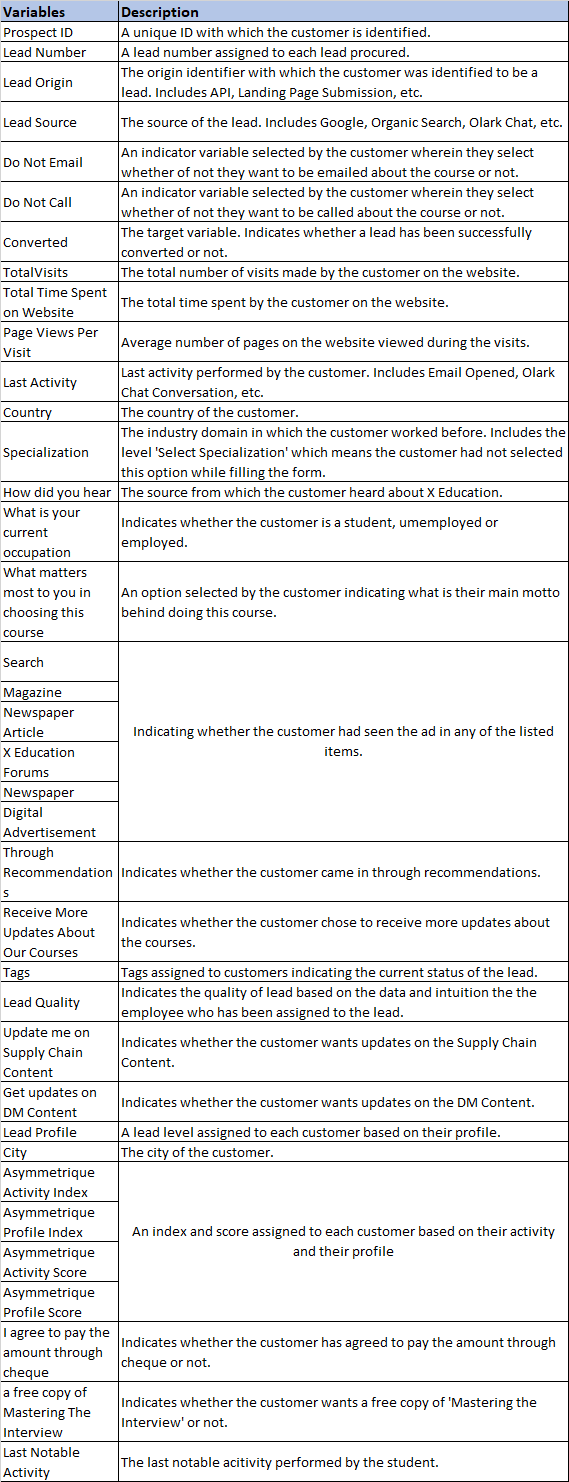

In [3]:
#Q1 (15 pt) -There are missing values in the Lead data.
#Replace missing values with the mean if the variable is numeric and  with the mode if the variable is categorical.
#Note: If the data type (Dtype) is object, the variable is categorical and
#if the data type (Dtype) is int64 or float64, the variable is numerical.

# I have to iterate through each column to fill missing values
for col in df.columns:
    if df[col].dtype == 'object': # first I check if the column type is categorical (object)
        mode_value = df[col].mode()[0] # here I calculate the mode and here I use [0] to get the most frequent value.
        df[col] = df[col].fillna(mode_value)

    elif df[col].dtype in ['int64', 'float64']: # now we check if the column type is numerical (int64 or float64)
        mean_value = df[col].mean() # mean calculation
        df[col] = df[col].fillna(mean_value)

print("Total missing values after imputation:", df.isnull().sum().sum()) # verification that there are no more missing values

Total missing values after imputation: 0


Label encoding is a technique used in machine learning to convert categorical data into numerical format. Each unique category value is assigned an integer value. For example, if you have a categorical feature like "color" with values "red," "green," and "blue," label encoding might transform these into 0, 1, and 2, respectively. This is useful because many machine learning algorithms require numerical input. However, it can imply an ordinal relationship where none exists, which might not be appropriate for all datasets.

When to Use

Use label encoding for ordinal data or tree-based models.

Use dummy variables for nominal data or models sensitive to ordinal assumptions such as linear regression

In [4]:
#Q2-(15 pt)Convert categorical variables to numerical with label encoder method .
#Drop Prospect ID,	Lead Number  and Converted from the input variables and use Converted as target variables.
#Split data into train and test using 30% of the data

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder() # first we have to convert categorical variables to numerical with label encoder method

for col in df.columns: # now we iterate through columns and apply LabelEncoder to categorical (object) columns
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(['Prospect ID', 'Lead Number', 'Converted'], axis=1) # here I drop columns from input variables (X)

y = df['Converted'] # we use 'Converted' as the target variable (y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) # train test split with 30% for testing

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (6468, 34)
X_test shape: (2772, 34)
y_train shape: (6468,)
y_test shape: (2772,)


In [ ]:
#Q3(10 pt) Assuming Converted = 1 represents the positive case (i.e., a lead converts into a customer),
# define what is false positive and false negative in this dataset?
#Which one is more important  metric (precison or recall) in this case? Why?

# False Positive is when the model predicts a lead will convert (1), but they actually do not convert (0).
# False Negative is when the model predicts a lead will not convert (0), but they actually do convert (1).

# In this dataset, a false positive means wasting sales effort on a lead who will not actually buy, while a false negative means losing potential revenue by ignoring a lead who would have converted.

# 2. Which metric is more important (Precision or Recall)?
# In this specific case, Recall is generally the more important metric, because the cost of a False Negative (completely missing out on a paying customer) is usually
# much higher than the cost of a False Positive (wasting a few minutes on a call or email). By focusing on maximizing Recall, you ensure the business casts a wider net and captures
# as many potential buyers as possible, minimizing the ones that slip through the cracks.

--- Decision Tree ---
Accuracy:  0.9030
Precision: 0.8811
Recall:    0.8672
AUC Score: 0.8987
Confusion Matrix:
[[1569  126]
 [ 143  934]]

--- Random Forest ---
Accuracy:  0.9203
Precision: 0.9196
Recall:    0.8709
AUC Score: 0.9699
Confusion Matrix:
[[1613   82]
 [ 139  938]]

--- Gradient Boosting ---
Accuracy:  0.9315
Precision: 0.9302
Recall:    0.8904
AUC Score: 0.9802
Confusion Matrix:
[[1623   72]
 [ 118  959]]

--- XGBoost ---
Accuracy:  0.9401
Precision: 0.9334
Recall:    0.9109
AUC Score: 0.9804
Confusion Matrix:
[[1625   70]
 [  96  981]]

--- LightGBM ---
Accuracy:  0.9387
Precision: 0.9315
Recall:    0.9090
AUC Score: 0.9822
Confusion Matrix:
[[1623   72]
 [  98  979]]



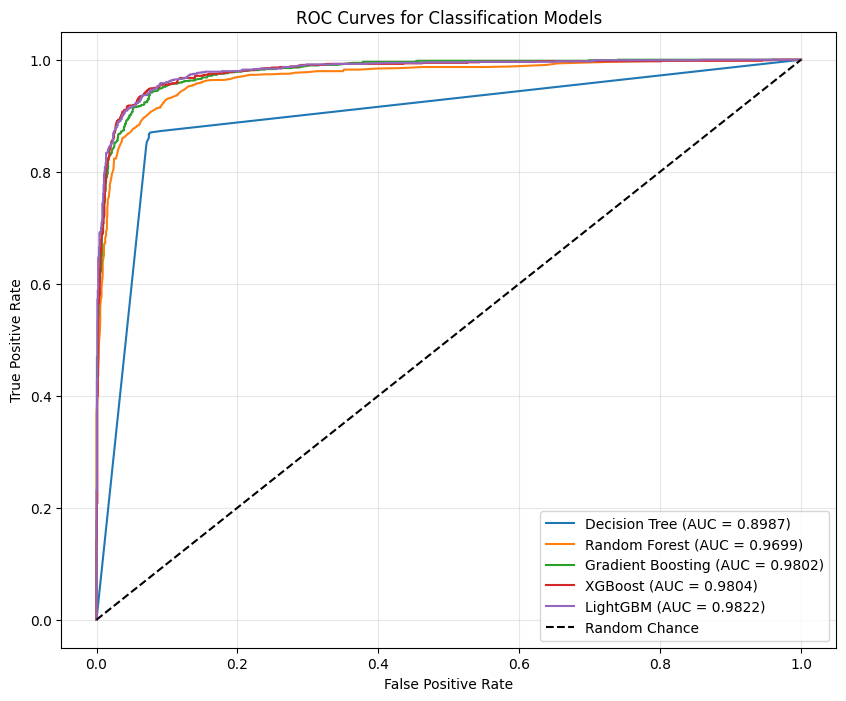

In [6]:
#Q4(60 pt)Use decison tree, random forest and boosting methods (XGBoost, LightGBM, GradingBoosting Method) to get
# the accuracy scores,precison and recall  on test  data.
# Report confusion metrics as well for these methods on test  data.
# Get the AUC score for this methods and draw ROC curve on test  data. .
#Which methods gave  best performance on test data based on accuracy metric,precison, recall metric and AUC soore?

import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_auc_score, roc_curve

# Models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1) # verbose=-1 suppresses LightGBM warnings
}

plt.figure(figsize=(10, 8)) # ROC curves plot

results = {} # Dictionary to store metrics for final comparison

# Iterate through each model to train, evaluate, and plot
for name, model in models.items():
    model.fit(X_train, y_train) # Training of the model

    # Prediction of classes and probabilities on test data
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] # Probability for class 1

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    cm = confusion_matrix(y_test, y_pred)

    #  Results
    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'AUC': auc}

    # data results
    print(f"--- {name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"AUC Score: {auc:.4f}")
    print(f"Confusion Matrix:\n{cm}\n")

    # False Positive Rate and True Positive Rate for ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

# Final ROC curve plot
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Classification Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()



# Which methods gave  best performance on test data based on accuracy metric,precison, recall metric and AUC soore?
# If we talk about accuracy, XGBoost achieved the highest accuracy (0.9401), meaning it had the highest overall percentage of correct predictions.
# Talking about precision: XGBoost achieved the highest precision (0.9334), meaning it had the lowest rate of false positives among the models.
# Recall: XGBoost achieved the highest recall (0.9109), meaning it was the best at successfully identifying actual converted leads.
# AUC Score: only in this score LightGBM achieved the highest AUC score (0.9822), meaning it was slightly better at distinguishing between the positive and negative classes across all probability thresholds.

# Overall, XGBoost gave the best performance on the test data. It dominated in Accuracy, Precision, and Recall, which are crucial
# for the actual business application. LightGBM holds a slight edge in the AUC score.